In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import matplotlib.ticker as ticker

from matplotlib.widgets import Slider
from scipy.spatial import cKDTree
from scipy.interpolate import RegularGridInterpolator
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d
from scipy.interpolate import KroghInterpolator
from scipy.integrate import quad
from numpy import simps

import h5py

In [2]:
#Cargar datos
LABELS = ["Alt_Si3N4", "Anc_Si3N4", "lambda", "n_eff", "A_eff"]

def load_and_normalize(fname):
    with h5py.File(fname, "r") as f:
        A = f["/A"][...]
    axis5 = next((ax for ax, s in enumerate(A.shape) if s == 5), None)
    if axis5 is None:
        raise ValueError(f"No encontré eje de tamaño 5 en {fname}")
    if axis5 != A.ndim - 1:
        A = np.moveaxis(A, axis5, -1)
    return A

In [3]:
archivos = [
    "Datos_reto/Datos9.h5",
    "Datos_reto/Datos11.h5"
]
datasets = [load_and_normalize(fname) for fname in archivos]

def check_borders(d1, d2):
    alt1_end = np.round(d1[-1,0,0,0],6)
    alt2_start = np.round(d2[0,0,0,0],6)
    anc1_end = np.round(d1[0,-1,0,1],6)
    anc2_start = np.round(d2[0,0,0,1],6)
    print(f"Check Alt: {alt1_end} vs {alt2_start}, Check Anc: {anc1_end} vs {anc2_start}")
    if not np.isclose(alt1_end, alt2_start) and not np.isclose(anc1_end, anc2_start):
        print("⚠️ Advertencia: los bordes no coinciden perfectamente")

for i in range(len(datasets)-1):
    check_borders(datasets[i], datasets[i+1])

DatosU = np.concatenate(datasets, axis=0)

Check Alt: 0.4 vs 0.4, Check Anc: 2.0 vs 0.5


In [4]:
with h5py.File("Datos_reto/DatosU.h5", "w") as f_out:
    f_out.create_dataset("A", data=DatosU)

print("✅ Dataset unificado guardado en DatosU.h5, shape:", DatosU.shape)

✅ Dataset unificado guardado en DatosU.h5, shape: (100, 10, 10, 5)


In [5]:
def to_dataframe(arr):
    nA, nB, nC, _ = arr.shape
    rows = []
    for ii in range(nA):
        for jj in range(nB):
            for kk in range(nC):
                rec = {"i": ii+1, "j": jj+1, "k": kk+1}
                for p, name in enumerate(LABELS):
                    rec[name] = arr[ii, jj, kk, p]
                rows.append(rec)
    return pd.DataFrame(rows, columns=["i","j","k"]+LABELS)

df = to_dataframe(DatosU)
df["lambda_nm"] = df["lambda"] * 1000 
print(df)

#Guarda todos los datos en un dataframe y donde i: lambdas, j: anchuras, k: alturas


        i   j   k  Alt_Si3N4  Anc_Si3N4  lambda     n_eff         A_eff  \
0       1   1   1   0.400000        0.5   1.035  1.594476  3.233126e-13   
1       1   1   2   0.466667        0.5   1.035  1.627080  3.328044e-13   
2       1   1   3   0.533333        0.5   1.035  1.652778  3.492393e-13   
3       1   1   4   0.600000        0.5   1.035  1.672627  3.684361e-13   
4       1   1   5   0.666667        0.5   1.035  1.688365  3.893655e-13   
...   ...  ..  ..        ...        ...     ...       ...           ...   
9995  100  10   6   0.733333        2.0   1.035  1.920578  9.078877e-13   
9996  100  10   7   0.800000        2.0   1.035  1.930293  9.668587e-13   
9997  100  10   8   0.866667        2.0   1.035  1.938219  1.026122e-12   
9998  100  10   9   0.933333        2.0   1.035  1.944864  1.086505e-12   
9999  100  10  10   1.000000        2.0   1.035  1.950377  1.146664e-12   

      lambda_nm  
0        1035.0  
1        1035.0  
2        1035.0  
3        1035.0  
4        

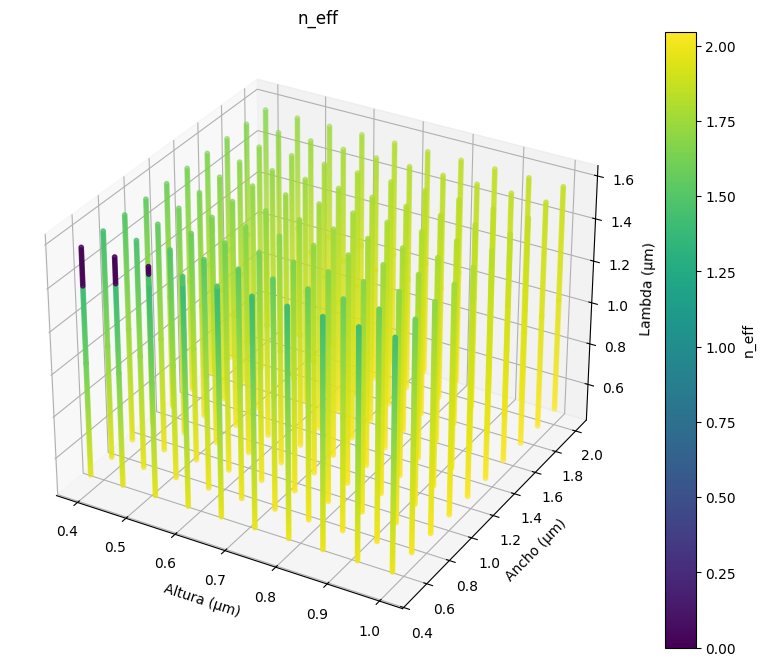

In [6]:
#Grafica N_efectivo
fig1 = plt.figure(figsize=(10,8))
ax1 = fig1.add_subplot(111, projection='3d')
p1 = ax1.scatter(df["Alt_Si3N4"], df["Anc_Si3N4"], df["lambda"],
                 c=df["n_eff"], cmap="viridis", s=10)
ax1.set_xlabel("Altura (µm)")
ax1.set_ylabel("Ancho (µm)")
ax1.set_zlabel("Lambda (µm)")
fig1.colorbar(p1, ax=ax1, label="n_eff")
ax1.set_title("n_eff")


plt.show()

Hallamos las intersecciones. Estamos interesados hallar intersecciones entre $\Delta K = 0$ y $\tau_s  = -\tau_i$

C:\Users\david\AppData\Local\Temp\ipykernel_18652\1016191066.py:39: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(lam_data, neff_data, grado_poly)
C:\Users\david\AppData\Local\Temp\ipykernel_18652\1016191066.py:39: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(lam_data, neff_data, grado_poly)
C:\Users\david\AppData\Local\Temp\ipykernel_18652\1016191066.py:39: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(lam_data, neff_data, grado_poly)
C:\Users\david\AppData\Local\Temp\ipykernel_18652\1016191066.py:39: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(lam_data, neff_data, grado_poly)
C:\Users\david\AppData\Local\Temp\ipykernel_18652\1016191066.py:39: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(lam_data, neff_data, grado_poly)
C:\Users\david\AppData\Local\Temp\ipykernel_18652\1016191066.py:39: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(lam_data, neff_data, grad

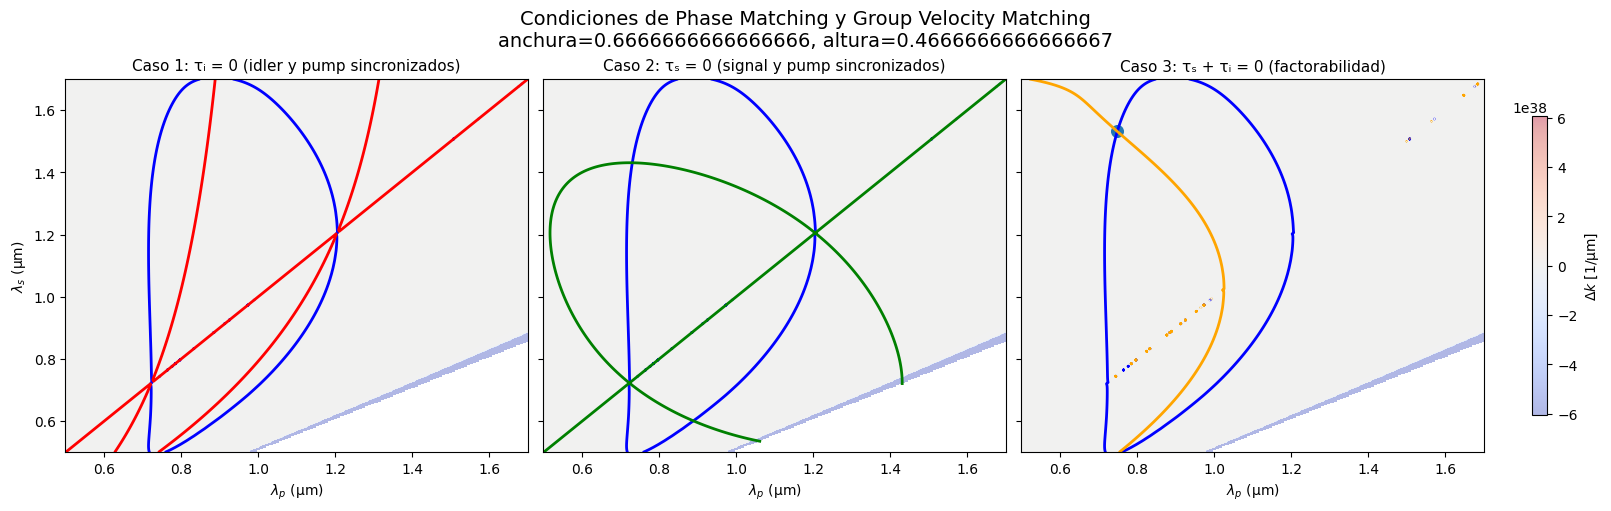

C:\Users\david\AppData\Local\Temp\ipykernel_18652\1016191066.py:39: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(lam_data, neff_data, grado_poly)
C:\Users\david\AppData\Local\Temp\ipykernel_18652\1016191066.py:39: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(lam_data, neff_data, grado_poly)
C:\Users\david\AppData\Local\Temp\ipykernel_18652\1016191066.py:39: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(lam_data, neff_data, grado_poly)
C:\Users\david\AppData\Local\Temp\ipykernel_18652\1016191066.py:39: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(lam_data, neff_data, grado_poly)
C:\Users\david\AppData\Local\Temp\ipykernel_18652\1016191066.py:39: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(lam_data, neff_data, grado_poly)
C:\Users\david\AppData\Local\Temp\ipykernel_18652\1016191066.py:39: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(lam_data, neff_data, grad

✅ Se analizaron 1 geometrías con intersecciones.
Total de puntos de intersección encontrados: 1
Primeras 4 geometrias
 j=2, k=2,
 puntos_12=1: [[ 7.48598131e-01  1.53149533e+00  4.95367371e-01 -8.93622314e-05
   5.19308684e-02 -5.20256321e-02 -9.47636229e-05]], 
 puntos_13=0: [],
 puntos_14=0: []


In [ ]:
#c = 2.99792458e14  #  micras/s
c = 1
grado_poly = 30

intersecciones = []


#Funciones generales

def neff(lam, p):
    return np.polyval(p, lam)

def neff_prime(lam, p):
    dp = np.polyder(p)
    return np.polyval(dp, lam)

def k(lam, p):
    return (2*np.pi/lam) * neff(lam, p)

def k_prime(lam, p): #Definidas sin la velocidad de la luz para evitar problemas
    return (1/c)*(neff(lam, p) - lam*(neff_prime(lam, p)))

# Búsqueda entre todas las geometrías

j_vals = sorted(df["j"].unique())
k_vals = sorted(df["k"].unique())
for j_val in j_vals:
    for k_val in k_vals:
        df_geom = df[(df["j"] == j_val) & (df["k"] == k_val)]
        if df_geom.empty:
            continue  # salta combinaciones sin datos
        
        lam_data = df_geom["lambda"].values
        neff_data = df_geom["n_eff"].values
        
        #print(f"Geometría j={j_val}, k={k_val}: {len(lam)} puntos válidos")

        #Calculamos las funciones importantes
        coef = np.polyfit(lam_data, neff_data, grado_poly)
        p = np.poly1d(coef)
        
        #Generamos las combinaciones de [l_bombeo, l_signal, l_idler]. 
        lamp = np.linspace(0.72, 0.890, 750)
        lams = np.linspace(1.530, 1.570, 750)
        LAMP, LAMS = np.meshgrid(lamp, lams)
        #Restringimos lami a aquellos que cumples conservacion de energia
        LAMI_ENERGY = 1 / (2 / LAMP - 1 / LAMS)

        #Generamos una mascara de valores booleanos que nos permitan acceder a los valores correctos de LAMI_ENERGY
        mask = np.isfinite(LAMI_ENERGY) &  (LAMI_ENERGY >= 0)# (LAMI_ENERGY >= 0.5) & (LAMI_ENERGY <= 0.68)

        Kp = k(LAMP, p)
        Ks = k(LAMS, p)
        Ki = np.full_like(Kp, np.nan)# Genera una estructura de datos de igual tamaño que Kp y los rellena de np.nan
        Ki[mask] = k(LAMI_ENERGY[mask], p)# Calcula las K_lamb de los valores de LAMI validos, y Ki[mask] los inserta en las posiciones correspondientes
                                     # Esto permite que  Ki siga teniendo el mismo tamaño que antes!
        
        DK = 2 * Kp - Ks - Ki

        #Retardos de grupo
        Taus = np.full_like(Kp, np.nan)
        Taui = np.full_like(Kp, np.nan)

        Taus[mask] = k_prime(LAMP[mask], p) - k_prime(LAMS[mask], p)
        Taui[mask] = k_prime(LAMP[mask], p) - k_prime(LAMI_ENERGY[mask], p)

        #Creamos diferentes mascaras para cada condicion. Creamos un margen de error epsilon para cada una de ellas
        epsilon = 1e-4
        mask_1 = (np.abs(DK) <= epsilon)
        mask_2 = (np.abs(Taus + Taui) <= epsilon )
        mask_3 = (np.abs(Taus) <= epsilon )
        mask_4 = (np.abs(Taui) <= epsilon )

        #Intersecciones
        mask_12 = mask_1 & mask_2
        mask_13 = mask_1 & mask_3
        mask_14 = mask_1 & mask_4

        #Extraemos las combinaciones de lambdas que cumplen las condiciones especificadas a traves de una matriz donde  cada fila corresponde a un punto.
        def extraer_lambdas(mask_int):
            lam_p = LAMP[mask_int]
            lam_s = LAMS[mask_int]
            lam_i = LAMI_ENERGY[mask_int]
            dk = DK[mask_int]
            tau_s = Taus[mask_int]
            tau_i = Taui[mask_int]

            matriz = np.array([lam_p, lam_s, lam_i, dk, tau_s, tau_i, tau_s + tau_i])
            matriz = np.transpose(matriz)
            return matriz

        matriz_12 = extraer_lambdas(mask_12)
        matriz_13 = extraer_lambdas(mask_13)
        matriz_14 = extraer_lambdas(mask_14)

        if (len(matriz_12) > 0) or (len(matriz_13) > 0) or (len(matriz_14) > 0):
            intersecciones.append({
                "j": j_val,
                "k": k_val,
                "puntos_12": matriz_12, 
                "puntos_13": matriz_13,
                "puntos_14": matriz_14,
                "Coeficientes": p       
            })
            #Graficamos en todo el rango de los lambdass
            lamp = np.linspace(0.5, 1.7, 300)
            lams = np.linspace(0.5, 1.7, 300)
            LAMP, LAMS = np.meshgrid(lamp, lams)
            #Restringimos lami a aquellos que cumples conservacion de energia
            LAMI_ENERGY = 1 / (2 / LAMP - 1 / LAMS)

            #Generamos una mascara de valores booleanos que nos permitan acceder a los valores físicamente validos de lambda idler
            mask = np.isfinite(LAMI_ENERGY) & (LAMI_ENERGY >0)

            Kp = k(LAMP, p)
            Ks = k(LAMS, p)
            Ki = np.full_like(Kp, np.nan)# Genera una estructura de datos de igual tamaño que Kp y los rellena de np.nan
            Ki[mask] = k(LAMI_ENERGY[mask], p)# Calcula las K_lamb de los valores de LAMI validos, y Ki[mask] los inserta en las posiciones correspondientes
                                        # Esto permite que  Ki siga teniendo el mismo tamaño que antes!
            
            DK = 2 * Kp - Ks - Ki

            #Retardos de grupo
            Taus = np.full_like(Kp, np.nan)
            Taui = np.full_like(Kp, np.nan)

            Taus[mask] = k_prime(LAMP[mask], p) - k_prime(LAMS[mask]for ax, title, color, tau, matriz in zip(axes, titles, colors, taus_list, [matriz_14, matriz_13, matriz_12]):
                matrizt = np.transpose(matriz)
                # Fondo: mapa Δk
                im = ax.imshow(DK, extent=[lamp.min(), lamp.max(), lams.min(), lams.max()],
                               origin='lower', aspect='auto', cmap='coolwarm',
                               alpha=0.4, vmin=vmin, vmax=vmax)
                # Contorno Δk = 0
                ax.contour(LAMP, LAMS, DK, levels=[0], colors='b', linewidths=2)
                # Contorno τ = 0
                ax.contour(LAMP, LAMS, tau, levels=[0], colors=color, linewidths=2)
                if len(matrizt)!=0:
                    ax.scatter(matrizt[0], matrizt[1], s=70)
                ax.set_title(title, fontsize=11)
                ax.set_xlabel(r'$\lambda_p$ (µm)')
                ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
                ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

            axes[0].set_ylabel(r'$\lambda_s$ (µm)')
            fig.colorbar(im, ax=axes, orientation='vertical', shrink=0.8,
                         label=r'$\Delta k$ [1/µm]', pad=0.02)
            fig.suptitle(
                f"Condiciones de Phase Matching y Group Velocity Matching\nanchura={df.loc[(df['j'] == 2) & (df['k'] == 2), 'Anc_Si3N4'].iloc[0]}, altura={df.loc[(df['j'] == 2) & (df['k'] == 2), 'Alt_Si3N4'].iloc[0]}",
                fontsize=14
            )
            plt.show(), p)
            Taui[mask] = k_prime(LAMP[mask], p) - k_prime(LAMI_ENERGY[mask], p)

            fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True,
                                     constrained_layout=True)
            titles = [
                "Caso 1: τᵢ = 0 (idler y pump sincronizados)",
                "Caso 2: τₛ = 0 (signal y pump sincronizados)",
                "Caso 3: τₛ + τᵢ = 0 (factorabilidad)"
            ]
            colors = ['r', 'g', 'orange']
            taus_list = [Taui, Taus, Taui + Taus]

            vmax = np.nanpercentile(np.abs(DK), 99)
            vmin = -vmax

            


#Mostrar resumen
print(f"✅ Se analizaron {len(intersecciones)} geometrías con intersecciones.")
total_pts = sum(len(d["puntos_12"]) + len(d["puntos_13"]) + len(d["puntos_14"]) for d in intersecciones)
print(f"Total de puntos de intersección encontrados: {total_pts}")

#Ejemplo: mostrar primeras n geometrias
n=4
print(f"Primeras {n} geometrias")
for d in intersecciones[:n]:
    print(f" j={d['j']}, k={d['k']},\n puntos_12={len(d['puntos_12'])}: {d["puntos_12"]}, \n puntos_13={len(d['puntos_13'])}: {d["puntos_13"]},\n puntos_14={len(d['puntos_14'])}: {d["puntos_14"]}")        

Hallamos la JSA. En teoría la funcion es una integral, pero la aproximacion a primer orden de esta corresponde a la multiplicacion de la amplitud espectral de las de bombeo multiplicado por las condiciones de phase matching.![Imagen de WhatsApp 2025-10-24 a las 21.03.20_19b51701.jpg](<attachment:Imagen de WhatsApp 2025-10-24 a las 21.03.20_19b51701.jpg>)

![Imagen de WhatsApp 2025-10-24 a las 19.55.36_efd03ab9.jpg](<attachment:Imagen de WhatsApp 2025-10-24 a las 19.55.36_efd03ab9.jpg>)
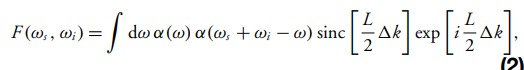
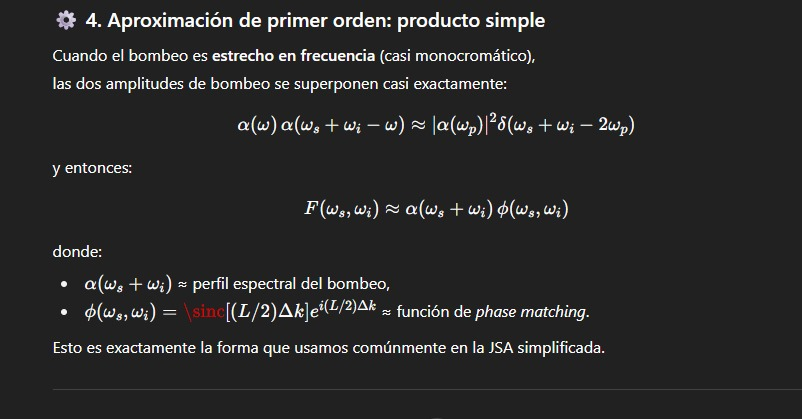

In [ ]:
# ==============================
# Constantes y parámetros
# ==============================
c = 2.99792458e14   # [µm/s]
L = 2e4             # [µm] (2 cm)
lambda_p0 = 0.775   # [µm]
sigma_p_lam = 0.005 # [µm] ancho en lambda (si usas alpha en λ)
sigma_p_om  = 2*np.pi*c*(1/(lambda_p0 - sigma_p_lam) - 1/lambda_p0)  # ancho aprox. en ω


def neff(lam, p):
    return np.polyval(p, lam)

def k(lam, p):
    return (2*np.pi/lam) * neff(lam, p)

def delta_k(lamp, lams, lami, p):
    return 2*k(lamp, p) - k(lams, p) - k(lami, p)

# Conversión ω↔λ
def omega_from_lambda(lam):  # lam en µm -> ω en rad/s
    return 2*np.pi*c/lam

def lambda_from_omega(om):   # ω en rad/s -> lam en µm
    return 2*np.pi*c/om

# Amplitud espectral del bombeo 
def alpha_omega(om, om0=None, sigma=None):
    """Alpha en dominio ω (rad/s)."""
    if om0 is None:
        om0 = omega_from_lambda(lambda_p0)
    if sigma is None:
        sigma = sigma_p_om
    return np.exp(-0.5*((om - om0)/sigma)**2)

def alpha_lambda(lam, lam0=lambda_p0, sigma=sigma_p_lam):
    """Alpha en dominio λ (µm)."""
    return np.exp(-0.5*((lam - lam0)/sigma)**2)

def F_integral(lambda_s, lambda_i, p, lambda_p_grid,
               alpha_domain='omega'):
    """
    Calcula F(λs, λi) = ∫ dω α(ω) α(ωs+ωi-ω) sinc(...) e^{i...}
    Integrando en λp con jacobiano |dω/dλ| = 2π c / λp^2.
    alpha_domain: 'omega' usa alpha_omega; 'lambda' usa alpha_lambda.
    """
    lam_p = lambda_p_grid  # [µm]
    om_s  = omega_from_lambda(lambda_s)
    om_i  = omega_from_lambda(lambda_i)
    om_p  = omega_from_lambda(lam_p)  # vector

    # Segundo bombeo por conservación de energía en SFWM: ω2 = ωs + ωi - ωp
    om_p2 = om_s + om_i - om_p
    # Filtrado físico: ω2 > 0  ->  lam_p2 > 0
    mask = om_p2 > 0
    lam_p = lam_p[mask]
    om_p  = om_p[mask]
    om_p2 = om_p2[mask]
    lam_p2 = lambda_from_omega(om_p2)

    # Phase-matching con p en λ:
    DK = delta_k(lam_p, lambda_s, lambda_i, p)
    phase_term = np.sinc((L/(2*np.pi))*DK) * np.exp(1j*(L/2)*DK)

    # Alphas y jacobiano
    if alpha_domain == 'omega':
        a1 = alpha_omega(om_p)
        a2 = alpha_omega(om_p2)
    else:  # 'lambda'
        a1 = alpha_lambda(lam_p)
        a2 = alpha_lambda(lam_p2)

    J = (2*np.pi*c)/(lam_p**2)  # |dω/dλ|  (positivo)

    integrand = a1 * a2 * phase_term * J
    F_val = np.trapz(integrand, lam_p)  # integrar en λp
    return F_val



p = intersecciones[0]["Coeficientes"]  

lambda_s_vals = np.linspace(0.5, 1.57, 1000)
lambda_i_vals = np.linspace(0.5, 1.57, 1000)
lambda_p_grid = np.linspace(0.5, 1.57, 1000)

F_mat = np.zeros((len(lambda_s_vals), len(lambda_i_vals)), dtype=complex)
for i, ls in enumerate(lambda_s_vals):
    for j, li in enumerate(lambda_i_vals):
        F_mat[i, j] = F_integral(ls, li, p, lambda_p_grid,
                                 alpha_domain='omega')  # o 'lambda'

JSI = np.abs(F_mat)**2
JSI /= JSI.max()

fig, axes = plt.subplots(1, 3, figsize=(18,5))

LAMS, LAMI = np.meshgrid(lambda_s_vals, lambda_i_vals)
ALPHA_VIS = alpha_lambda((LAMS+LAMI)/2) if True else alpha_omega(omega_from_lambda((LAMS+LAMI)/2))
axes[0].imshow(ALPHA_VIS, extent=[lambda_s_vals.min(), lambda_s_vals.max(),
                                  lambda_i_vals.min(), lambda_i_vals.max()],
               origin='lower', cmap='viridis', aspect='auto')
axes[0].set_title("Banda de bombeo (visualización de alphas)")
axes[0].set_xlabel(r'$\lambda_s$ (µm)')
axes[0].set_ylabel(r'$\lambda_i$ (µm)')

# (b) Phase matching (|sinc|) para λp ≈ (λs+λi)/2 como guía visual
DK_vis = delta_k((LAMS+LAMI)/2, LAMS, LAMI, p)
axes[1].imshow(np.abs(np.sinc((L/(2*np.pi))*DK_vis)),
               extent=[lambda_s_vals.min(), lambda_s_vals.max(),
                       lambda_i_vals.min(), lambda_i_vals.max()],
               origin='lower', cmap='coolwarm', aspect='auto')
axes[1].set_title(r'Phase matching (guía): $|\mathrm{sinc}(ΔkL/2\pi)|$')
axes[1].set_xlabel(r'$\lambda_s$ (µm)')
axes[1].set_ylabel(r'$\lambda_i$ (µm)')

# (c) Resultado integral: JSI = |F|^2
axes[2].imshow(JSI, extent=[1.535, 1.545,
                            0.455, 0.465],
               origin='lower', cmap='inferno', aspect='auto')
axes[2].set_title(r'JSI $= |F(\lambda_s,\lambda_i)|^2$ (inte    gral real con jacobiano)')
axes[2].set_xlabel(r'$\lambda_s$ (µm)')
axes[2].set_ylabel(r'$\lambda_i$ (µm)')

plt.tight_layout()
plt.show()


C:\Users\david\AppData\Local\Temp\ipykernel_18652\1768544203.py:76: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  F_val = np.trapz(integrand, lam_p)  # integrar en λp


KeyboardInterrupt: 